In [1]:
import pandas as pd
import os
import plotly.graph_objects as go

sid, landmarks, t0(x,y), t1(x,y),mae t0-t1, t2(x,y), mae t1-t2, t3(x,y), mae t2-t3
10-15

In [20]:
def load_preds_for_landmarks(landmarks, hop=1, deg=2,
                             model_tag="sex_adaptive",
                             preds_dir="./preds"):
    """Return dict: landmark -> df."""
    out = {}
    for lm in landmarks:
        fname = f"preds_{lm.replace(' ', '_')}_hop{hop}_deg{deg}_{model_tag}.csv"
        path = os.path.join(preds_dir, fname)
        if not os.path.exists(path):
            print(f"[WARN] File not found for landmark '{lm}': {path}")
            continue
        out[lm] = pd.read_csv(path)
    return out

In [21]:
landmarks = ['nasion',
             'point a','point b',
             'pogonion','menton',
            'condyle','pns','basion',
             'ans','mid gonion']

In [22]:
import numpy as np
import pandas as pd

def make_wide_for_landmark(df, max_t=4, sort_col="age"):
    """
    Take a long df for ONE landmark and turn it into wide format:
    sid, sex, landmark, t0, t0x_true, t0y_true, t0x_pred, t0y_pred, ...
    """
    by_sid = {sid: g for sid, g in df.groupby("sid")}
    rows = []

    for sid, g in by_sid.items():
        # sort by age so t0,t1,t2,t3 are in temporal order
        g = g.sort_values(sort_col).reset_index(drop=True)

        row = {
            "sid": sid,
            "sex": g.loc[0, "sex"],        # same within sid
            "landmark": g.loc[0, "landmark"],
        }

        for t in range(max_t):
            if t < len(g):
                r = g.loc[t]
                row[f"t{t}"]       = r["age"]
                row[f"t{t}x_true"] = r["x_true"]
                row[f"t{t}y_true"] = r["y_true"]
                row[f"t{t}x_pred"] = r["x_pred"]
                row[f"t{t}y_pred"] = r["y_pred"]
            else:
                # pad with NaNs if this sid has fewer than max_t rows
                row[f"t{t}"]       = np.nan
                row[f"t{t}x_true"] = np.nan
                row[f"t{t}y_true"] = np.nan
                row[f"t{t}x_pred"] = np.nan
                row[f"t{t}y_pred"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

# ---------------- main usage ----------------

# load all preds once for all landmarks
pred_dict = load_preds_for_landmarks(landmarks)

lo, hi = 9, 15
tol = 0.5

for l in landmarks:
    # use the current landmark, not 'point a' hard-coded
    df = pred_dict[l]

    # age filter
    df_filtered = df[df["age"].between(lo - tol, hi + tol)]

    # build wide df for this landmark
    wide_df = make_wide_for_landmark(df_filtered, max_t=4)

    # save with landmark name
    wide_df.to_excel(f"{l}_wide.xlsx", index=False)


In [24]:
dfs = []

for l in landmarks:
    df = pd.read_excel(f"{l}_wide.xlsx")
    df["landmark_name"] = l   # if not already present / to be explicit
    dfs.append(df)
    print(f"Landmark: {l}, sample:")
    print(df.head())
    print("")

all_landmark_dfs = pd.concat(dfs, ignore_index=True)
all_landmark_dfs.to_excel("all_landmarks_wide.xlsx", index=False)

Landmark: nasion, sample:
     sid sex landmark      t0  t0x_true  t0y_true   t0x_pred  t0y_pred  \
0    003   M   nasion  11.670      81.8         0  81.781850         0   
1    007   F   nasion  10.167      66.2         0  66.548109         0   
2    008   F   nasion  10.750      70.0         0  69.902505         0   
3    013   M   nasion  10.580      73.2         0  73.427510         0   
4  02286   F   nasion  10.500      77.6         0  77.765521         0   

       t1  t1x_true  ...  t2x_true  t2y_true   t2x_pred  t2y_pred      t3  \
0  14.000      82.8  ...      82.9       0.0  84.114695       0.0     NaN   
1  11.250      67.1  ...      67.7       0.0  67.838393       0.0     NaN   
2     NaN       NaN  ...       NaN       NaN        NaN       NaN     NaN   
3  11.670      75.0  ...      75.5       0.0  76.206484       0.0  15.000   
4  11.417      78.0  ...      77.9       0.0  78.678584       0.0  13.833   

   t3x_true  t3y_true   t3x_pred  t3y_pred  landmark_name  
0     

In [ ]:
pred_dict = load_preds_for_landmarks(landmarks)


In [7]:
pred_dict['point a'].columns

Index(['sid', 'landmark', 'sex', 'age', 'age_next', 'dt', 'x_pred', 'y_pred',
       'x_true', 'y_true'],
      dtype='object')

In [8]:
lo, hi = 9, 15
tol = 0.5

df = pred_dict['point a']

df_filtered = df[df['age'].between(lo - tol, hi + tol)]

by_sid = {
    sid: g for sid, g in df_filtered.groupby("sid")
}

In [ ]:
import numpy as np
import pandas as pd

rows = []

for sid, g in by_sid.items():
    # sort by age so t0,t1,t2,t3 are in temporal order
    g = g.sort_values("age").reset_index(drop=True)
    
    row = {
        "sid": sid,
        "sex": g.loc[0, "sex"],          # same within sid
        "landmark": g.loc[0, "landmark"]
    }
    
    # up to t0..t3 (4 timepoints)
    for t in range(4):
        if t < len(g):
            r = g.loc[t]
            row[f"t{t}"]         = r["age"]
            row[f"t{t}x_true"]   = r["x_true"]
            row[f"t{t}y_true"]   = r["y_true"]
            row[f"t{t}x_pred"]   = r["x_pred"]
            row[f"t{t}y_pred"]   = r["y_pred"]
        else:
            # pad with NaNs if this sid has fewer than 4 rows
            row[f"t{t}"]         = np.nan
            row[f"t{t}x_true"]   = np.nan
            row[f"t{t}y_true"]   = np.nan
            row[f"t{t}x_pred"]   = np.nan
            row[f"t{t}y_pred"]   = np.nan
    
    rows.append(row)

wide_df = pd.DataFrame(rows)
name = "point a"

wide_df.to_excel(f"{name}_wide.xlsx", index=False)


In [19]:
by_sid['003']

,sid,landmark,sex,age,age_next,dt,x_pred,y_pred,x_true,y_true
0,003,point a,M,11.67,14.00,2.33,70.727485,-67.331373,67.8,-70.2
1,003,point a,M,14.00,15.25,1.25,68.962453,-71.546864,68.0,-70.3
2,003,point a,M,15.25,16.42,1.17,68.908899,-71.314306,69.6,-70.8


In [65]:
wide_df.columns

Index(['sid', 'sex', 'landmark', 't0', 't0x_true', 't0y_true', 't0x_pred',
       't0y_pred', 't1', 't1x_true', 't1y_true', 't1x_pred', 't1y_pred', 't2',
       't2x_true', 't2y_true', 't2x_pred', 't2y_pred', 't3', 't3x_true',
       't3y_true', 't3x_pred', 't3y_pred'],
      dtype='object')

In [64]:
wide_df.to_excel("point_a_wide.xlsx", index=False)

In [2]:
wide_df = pd.read_excel("point_a_wide.xlsx")

In [3]:
wide_male = wide_df[wide_df['sex']=='M']
wide_female = wide_df[wide_df['sex']=='F']

In [21]:
wide_male

,sid,sex,landmark,t0,t0x_true,t0y_true,t0x_pred,t0y_pred,t1,t1x_true,...,t2,t2x_true,t2y_true,t2x_pred,t2y_pred,t3,t3x_true,t3y_true,t3x_pred,t3y_pred
0,003,M,point a,11.67,67.8,-70.2,70.727485,-67.331373,14.00,68.0,...,15.250,69.6,-70.8,68.908899,-71.314306,NaN,NaN,NaN,NaN,NaN
3,013,M,point a,10.58,66.0,-55.7,66.753848,-56.502766,11.67,66.0,...,13.830,67.9,-60.7,67.095256,-61.499179,15.00,69.9,-60.0,68.764319,-61.840663
5,02377,M,point a,10.50,70.7,-58.3,70.801528,-60.089900,11.50,71.8,...,12.500,73.6,-60.8,72.677371,-62.282053,13.25,74.1,-62.2,74.641001,-62.211439
8,B0113,M,point a,10.00,57.0,-50.6,57.812876,-51.093240,11.00,58.6,...,12.000,61.2,-52.5,59.534788,-52.738089,13.00,63.2,-57.0,63.586971,-55.678576
9,B0387,M,point a,13.92,64.8,-53.9,63.660878,-53.509284,14.83,65.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,B1167,M,point a,11.00,67.3,-54.4,67.398448,-54.429947,12.00,68.7,...,13.000,71.3,-58.9,69.518930,-56.367416,14.00,73.0,-60.1,72.989425,-61.068470
11,B1168,M,point a,11.00,62.1,-52.1,60.640315,-53.714425,12.00,66.2,...,13.830,66.3,-55.7,67.151696,-58.556810,14.92,67.7,-57.2,67.665207,-57.473871
12,B1204,M,point a,10.00,61.0,-52.5,59.618735,-53.490247,11.00,61.3,...,12.000,62.0,-55.4,62.219744,-55.273146,13.00,63.6,-55.9,62.955299,-56.814793
13,B1892,M,point a,10.00,68.5,-61.2,64.903081,-61.899354,11.00,68.6,...,12.000,69.9,-64.6,69.685732,-63.975857,13.00,73.5,-66.5,71.029660,-65.866719
14,B2130,M,point a,10.00,64.2,-53.3,63.598693,-51.790954,11.08,67.9,...,12.420,69.5,-56.6,68.358766,-56.824854,NaN,NaN,NaN,NaN,NaN


In [ ]:
import numpy as np

for t in range(4):
    x_true = wide_df[f"t{t}x_true"]
    y_true = wide_df[f"t{t}y_true"]
    x_pred = wide_df[f"t{t}x_pred"]
    y_pred = wide_df[f"t{t}y_pred"]
    
    wide_df[f"error_t{t}"] = np.sqrt((x_true - x_pred)**2 + (y_true - y_pred)**2)


In [49]:
## create bin for all ages 9-15
ages_t0  = wide_df['t0']
ages_t1  = wide_df['t1']
ages_t2  = wide_df['t2']
ages_t3  = wide_df['t3']

print(ages_t0.min(), ages_t0.max())
print(ages_t1.min(), ages_t1.max())
print(ages_t2.min(), ages_t2.max())
print(ages_t3.min(), ages_t3.max())


10.0 13.92
10.92 14.83
11.5 15.25
11.75 15.0


In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

def plot_tx_scatter(wide_df, t, x_min=None, x_max=None, y_min=None, y_max=None):
    """
    Make a scatter for timepoint t (0..3) using wide_df.
    wide_df columns: sid, sex, landmark, t0, t0x_true, t0y_true, t0x_pred, t0y_pred, ...
    """
    age_col     = f"t{t}"
    x_true_col  = f"t{t}x_true"
    y_true_col  = f"t{t}y_true"
    x_pred_col  = f"t{t}x_pred"
    y_pred_col  = f"t{t}y_pred"

    # keep only rows that actually have this timepoint
    df_t = wide_df[~wide_df[age_col].isna()].copy()
    if df_t.empty:
        print(f"No data for t{t}")
        return None

    # actual rows
    actual = df_t.assign(
        x=df_t[x_true_col],
        y=df_t[y_true_col],
        kind="Actual",
        age=df_t[age_col],
    )[["sid", "sex", "landmark", "age", "x", "y", "kind"]]

    # predicted rows
    pred = df_t.assign(
        x=df_t[x_pred_col],
        y=df_t[y_pred_col],
        kind="Predicted",
        age=df_t[age_col],
    )[["sid", "sex", "landmark", "age", "x", "y", "kind"]]

    # concat instead of .append (pandas 2.x)
    long_df = pd.concat([actual, pred], ignore_index=True)

    fig = px.scatter(
        long_df,
        x="x",
        y="y",
        color="kind",
        symbol="kind",
        hover_data=["sid", "age", "sex", "landmark","kind"],
        title=f"t{t} – Actual vs Predicted"
    )
    if x_min is not None and x_max is not None:
        fig.update_xaxes(range=[x_min, x_max])
        fig.update_yaxes(range=[y_min, y_max])
    else:
        fig.update_yaxes(scaleanchor="x")
    fig.update_layout(
        xaxis_title="x (mm)",
        yaxis_title="y (mm)",
        legend_title="",
    )

    # nicer hover
    fig.update_traces(
        hovertemplate=(
            "kind=%{customdata[4]}<br>"
            "sid=%{customdata[0]}<br>"
            "age=%{customdata[1]}<br>"
            "sex=%{customdata[2]}<br>"
            "lm=%{customdata[3]}<br>"
            "x=%{x:.2f}, y=%{y:.2f}<extra></extra>"
        )
    )

    fig.show()
    return fig


In [ ]:
plot_tx_scatter(wide_male, 0, 55,75,-75,-45)  # t0
plot_tx_scatter(wide_male, 1, 55,75,-75,-45)  # t1
# plot_tx_scatter(wide_male, 2)  # t2
# plot_tx_scatter(wide_male, 3)  # t3


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_all_t_with_circles_matplotlib(
    wide_df,
    t_list=(0, 1, 2, 3),
    radius_min_mm: float = 2.0,
    radius_quantile: float = 0.75,
    x_min=None,
    x_max=None,
    y_min=None,
    y_max=None,
    min_span_mm: float = 20.0,   # minimum visible span per axis
    save_path: str = None
):
    """
    Matplotlib version of 'Actual vs Predicted for t0–t3' with one circle per t.

    - White background
    - Actual = circles, Predicted = crosses
    - One dotted circle per t around mean of Actual, radius from quantile of distances
    - Axis limits auto-computed to tightly include all circles, with small padding
    - Optional manual crop via x_min/x_max/y_min/y_max
    """

    # ---- collect all points & circle params ----
    frames = []
    circle_params = {}  # t_label -> (cx, cy, radius)

    for t in t_list:
        age_col    = f"t{t}"
        x_true_col = f"t{t}x_true"
        y_true_col = f"t{t}y_true"
        x_pred_col = f"t{t}x_pred"
        y_pred_col = f"t{t}y_pred"

        # skip if cols missing
        if age_col not in wide_df.columns:
            continue

        df_t = wide_df[~wide_df[age_col].isna()].copy()
        if df_t.empty:
            continue

        t_label = f"t{t}"

        actual = df_t.assign(
            x=df_t[x_true_col],
            y=df_t[y_true_col],
            age=df_t[age_col],
            kind="Actual",
            t=t_label,
        )[["sid", "sex", "landmark", "age", "x", "y", "kind", "t"]]

        pred = df_t.assign(
            x=df_t[x_pred_col],
            y=df_t[y_pred_col],
            age=df_t[age_col],
            kind="Predicted",
            t=t_label,
        )[["sid", "sex", "landmark", "age", "x", "y", "kind", "t"]]

        frames.append(actual)
        frames.append(pred)

        # ---- compute per-t circle from Actual ----
        sub = actual
        if not sub.empty:
            cx = sub["x"].mean()
            cy = sub["y"].mean()
            dists = np.sqrt((sub["x"] - cx) ** 2 + (sub["y"] - cy) ** 2)
            radius = max(radius_min_mm, float(np.quantile(dists, radius_quantile)))
            circle_params[t_label] = (cx, cy, radius)

    if not frames:
        print("No data for any requested timepoints.")
        return

    long_df = pd.concat(frames, ignore_index=True)

    # ---- compute global bounds including all circles (like your MPL function) ----
    global_min_x = global_max_x = None
    global_min_y = global_max_y = None

    for t_label, (cx, cy, radius) in circle_params.items():
        local_min_x = cx - radius
        local_max_x = cx + radius
        local_min_y = cy - radius
        local_max_y = cy + radius

        if global_min_x is None:
            global_min_x, global_max_x = local_min_x, local_max_x
            global_min_y, global_max_y = local_min_y, local_max_y
        else:
            global_min_x = min(global_min_x, local_min_x)
            global_max_x = max(global_max_x, local_max_x)
            global_min_y = min(global_min_y, local_min_y)
            global_max_y = max(global_max_y, local_max_y)

    # fallback if something weird
    if global_min_x is None:
        global_min_x = long_df["x"].min()
        global_max_x = long_df["x"].max()
        global_min_y = long_df["y"].min()
        global_max_y = long_df["y"].max()

    # ---- enforce minimum span per axis ----
    eff_min_span = max(min_span_mm, 2 * radius_min_mm + 1.0)

    span_x = global_max_x - global_min_x
    if span_x < eff_min_span:
        cx = 0.5 * (global_min_x + global_max_x)
        global_min_x = cx - eff_min_span / 2.0
        global_max_x = cx + eff_min_span / 2.0

    span_y = global_max_y - global_min_y
    if span_y < eff_min_span:
        cy = 0.5 * (global_min_y + global_max_y)
        global_min_y = cy - eff_min_span / 2.0
        global_max_y = cy + eff_min_span / 2.0

    # small padding (3%) like in your other function
    span_x = global_max_x - global_min_x
    span_y = global_max_y - global_min_y
    pad_x = 0.03 * span_x
    pad_y = 0.03 * span_y

    auto_x_min = global_min_x - pad_x
    auto_x_max = global_max_x + pad_x
    auto_y_min = global_min_y - pad_y
    auto_y_max = global_max_y + pad_y

    # final limits (manual overrides if provided)
    final_x_min = auto_x_min if x_min is None else x_min
    final_x_max = auto_x_max if x_max is None else x_max
    final_y_min = auto_y_min if y_min is None else y_min
    final_y_max = auto_y_max if y_max is None else y_max

    # ---- Matplotlib plotting ----
    fig, ax = plt.subplots(figsize=(8, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.grid(False)

    color_cycle = plt.get_cmap("tab10").colors
    t_labels = sorted(long_df["t"].unique())
    color_map = {t_label: color_cycle[i % len(color_cycle)] for i, t_label in enumerate(t_labels)}

    # plot points + error segments
    for t_label in t_labels:
        sub_act = long_df[(long_df["t"] == t_label) & (long_df["kind"] == "Actual")]
        sub_pred = long_df[(long_df["t"] == t_label) & (long_df["kind"] == "Predicted")]
        color = color_map[t_label]

        if not sub_act.empty:
            ax.scatter(
                sub_act["x"], sub_act["y"],
                s=40, marker="o", color=color,
                label=f"{t_label}, Actual"
            )
        if not sub_pred.empty:
            ax.scatter(
                sub_pred["x"], sub_pred["y"],
                s=40, marker="x", color=color,
                label=f"{t_label}, Predicted"
            )

        # draw small dotted segments from actual to predicted (matching rows by index)
        if not sub_act.empty and not sub_pred.empty:
            # align by index order
            n = min(len(sub_act), len(sub_pred))
            xa = sub_act["x"].to_numpy()[:n]
            ya = sub_act["y"].to_numpy()[:n]
            xp = sub_pred["x"].to_numpy()[:n]
            yp = sub_pred["y"].to_numpy()[:n]
            for xt, yt, xp_, yp_ in zip(xa, ya, xp, yp):
                ax.plot([xt, xp_], [yt, yp_], color="gray", linewidth=0.7, linestyle="dotted")

    # add group circles & labels
    if len(t_list) > 1:
        for t_label, (cx, cy, radius) in circle_params.items():
            circ = Circle(
                (cx, cy),
                radius,
                edgecolor="black",
                facecolor="none",
                linewidth=1.2,
                linestyle="dotted"
            )
            ax.add_patch(circ)
            ax.text(cx, cy + radius, t_label, ha="center", va="bottom", fontsize=10)

    # axes, aspect, limits
    ax.set_title("Actual vs Predicted for t0–t1", fontsize=18)
    ax.set_xlabel("x (mm)", fontsize=16)
    ax.set_ylabel("y (mm)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlim(final_x_min, final_x_max)
    ax.set_ylim(final_y_min, final_y_max)

    ax.legend(fontsize=10, loc="best")

    # trim extra whitespace around plot area
    fig.tight_layout()
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.08)

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


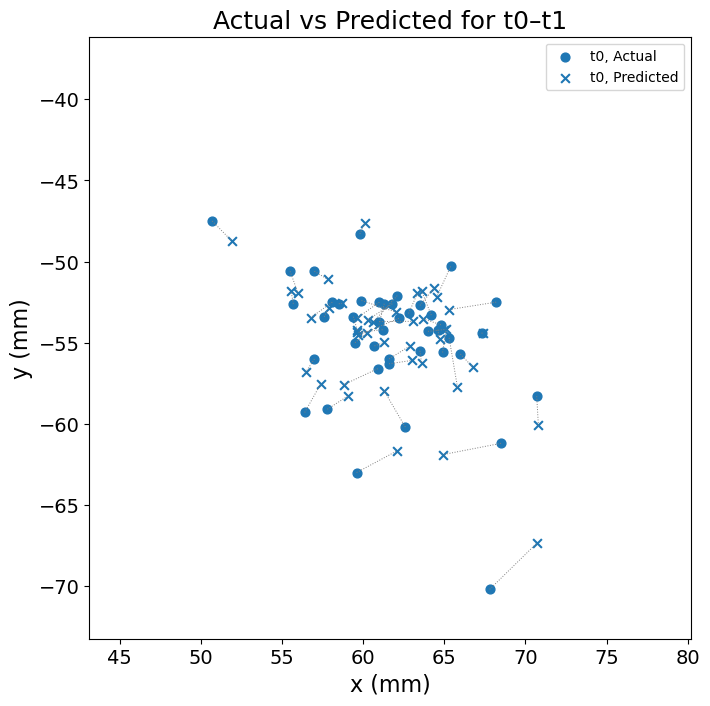

In [14]:
plot_all_t_with_circles_matplotlib(wide_df,t_list=[0],save_path="point_a_all_t_circles.png",min_span_mm=35.0)

In [ ]:
for i in landmarks:
    

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_all_t_with_circles_matplotlib(
    wide_df,
    t_list=(0, 1, 2, 3),
    radius_min_mm: float = 2.0,
    radius_quantile: float = 0.75,
    x_min=None,
    x_max=None,
    y_min=None,
    y_max=None,
    min_span_mm: float = 20.0,   # minimum visible span per axis
    save_path: str = None,
    title: str = None
):
    """
    Matplotlib version of 'Actual vs Predicted for t0–t3' with one circle per t.

    - White background
    - Actual = circles, Predicted = crosses
    - One dotted circle per t around mean of Actual, radius from quantile of distances
    - Axis limits auto-computed to tightly include all circles, with small padding
    - Optional manual crop via x_min/x_max/y_min/y_max

    EXTRA:
    - If there is only ONE t in t_list, color is assigned per SID (not per t).
    """

    # ---- collect all points & circle params ----
    frames = []
    circle_params = {}  # t_label -> (cx, cy, radius)

    for t in t_list:
        age_col    = f"t{t}"
        x_true_col = f"t{t}x_true"
        y_true_col = f"t{t}y_true"
        x_pred_col = f"t{t}x_pred"
        y_pred_col = f"t{t}y_pred"

        # skip if cols missing
        if age_col not in wide_df.columns:
            continue

        df_t = wide_df[~wide_df[age_col].isna()].copy()
        if df_t.empty:
            continue

        t_label = f"t{t}"

        actual = df_t.assign(
            x=df_t[x_true_col],
            y=df_t[y_true_col],
            age=df_t[age_col],
            kind="Actual",
            t=t_label,
        )[["sid", "sex", "landmark", "age", "x", "y", "kind", "t"]]

        pred = df_t.assign(
            x=df_t[x_pred_col],
            y=df_t[y_pred_col],
            age=df_t[age_col],
            kind="Predicted",
            t=t_label,
        )[["sid", "sex", "landmark", "age", "x", "y", "kind", "t"]]

        frames.append(actual)
        frames.append(pred)

        # ---- compute per-t circle from Actual ----
        sub = actual
        if not sub.empty:
            cx = sub["x"].mean()
            cy = sub["y"].mean()
            dists = np.sqrt((sub["x"] - cx) ** 2 + (sub["y"] - cy) ** 2)
            radius = max(radius_min_mm, float(np.quantile(dists, radius_quantile)))
            circle_params[t_label] = (cx, cy, radius)

    if not frames:
        print("No data for any requested timepoints.")
        return

    long_df = pd.concat(frames, ignore_index=True)

    # ---- compute global bounds including all circles ----
    global_min_x = global_max_x = None
    global_min_y = global_max_y = None

    for t_label, (cx, cy, radius) in circle_params.items():
        local_min_x = cx - radius
        local_max_x = cx + radius
        local_min_y = cy - radius
        local_max_y = cy + radius

        if global_min_x is None:
            global_min_x, global_max_x = local_min_x, local_max_x
            global_min_y, global_max_y = local_min_y, local_max_y
        else:
            global_min_x = min(global_min_x, local_min_x)
            global_max_x = max(global_max_x, local_max_x)
            global_min_y = min(global_min_y, local_min_y)
            global_max_y = max(global_max_y, local_max_y)

    # fallback if something weird
    if global_min_x is None:
        global_min_x = long_df["x"].min()
        global_max_x = long_df["x"].max()
        global_min_y = long_df["y"].min()
        global_max_y = long_df["y"].max()

    # ---- enforce minimum span per axis ----
    eff_min_span = max(min_span_mm, 2 * radius_min_mm + 1.0)

    span_x = global_max_x - global_min_x
    if span_x < eff_min_span:
        cx = 0.5 * (global_min_x + global_max_x)
        global_min_x = cx - eff_min_span / 2.0
        global_max_x = cx + eff_min_span / 2.0

    span_y = global_max_y - global_min_y
    if span_y < eff_min_span:
        cy = 0.5 * (global_min_y + global_max_y)
        global_min_y = cy - eff_min_span / 2.0
        global_max_y = cy + eff_min_span / 2.0

    # small padding (3%)
    span_x = global_max_x - global_min_x
    span_y = global_max_y - global_min_y
    pad_x = 0.03 * span_x
    pad_y = 0.03 * span_y

    auto_x_min = global_min_x - pad_x
    auto_x_max = global_max_x + pad_x
    auto_y_min = global_min_y - pad_y
    auto_y_max = global_max_y + pad_y

    # final limits (manual overrides if provided)
    final_x_min = auto_x_min if x_min is None else x_min
    final_x_max = auto_x_max if x_max is None else x_max
    final_y_min = auto_y_min if y_min is None else y_min
    final_y_max = auto_y_max if y_max is None else y_max

    # ---- Matplotlib plotting ----
    fig, ax = plt.subplots(figsize=(8, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.grid(False)

    color_cycle = plt.get_cmap("tab10").colors
    t_labels = sorted(long_df["t"].unique())

    # NEW: decide whether to color by t or by sid
    use_sid_colors = (len(t_labels) == 1)  # only one t present
    if use_sid_colors:
        sid_labels = sorted(long_df["sid"].unique())
        color_map_sid = {
            sid_val: color_cycle[i % len(color_cycle)]
            for i, sid_val in enumerate(sid_labels)
        }
    else:
        color_map_t = {
            t_label: color_cycle[i % len(color_cycle)]
            for i, t_label in enumerate(t_labels)
        }

    # plot points + error segments
    for t_label in t_labels:
        sub_act = long_df[(long_df["t"] == t_label) & (long_df["kind"] == "Actual")]
        sub_pred = long_df[(long_df["t"] == t_label) & (long_df["kind"] == "Predicted")]

        if use_sid_colors:
            # ---- color per SID ----
            # Actual
            for sid_val, sub_sid_act in sub_act.groupby("sid"):
                color = color_map_sid[sid_val]
                ax.scatter(
                    sub_sid_act["x"],
                    sub_sid_act["y"],
                    s=40,
                    marker="o",
                    color=color,
                )
            # Predicted
            for sid_val, sub_sid_pred in sub_pred.groupby("sid"):
                color = color_map_sid[sid_val]
                ax.scatter(
                    sub_sid_pred["x"],
                    sub_sid_pred["y"],
                    s=40,
                    marker="x",
                    color=color,
                )
        else:
            # ---- original behavior: color per t ----
            color = color_map_t[t_label]
            if not sub_act.empty:
                ax.scatter(
                    sub_act["x"], sub_act["y"],
                    s=40, marker="o", color=color,
                    label=f"{t_label}, Actual"
                )
            if not sub_pred.empty:
                ax.scatter(
                    sub_pred["x"], sub_pred["y"],
                    s=40, marker="x", color=color,
                    label=f"{t_label}, Predicted"
                )

        # draw small dotted segments from actual to predicted (matching rows by index)
        if not sub_act.empty and not sub_pred.empty:
            n = min(len(sub_act), len(sub_pred))
            xa = sub_act["x"].to_numpy()[:n]
            ya = sub_act["y"].to_numpy()[:n]
            xp = sub_pred["x"].to_numpy()[:n]
            yp = sub_pred["y"].to_numpy()[:n]
            for xt, yt, xp_, yp_ in zip(xa, ya, xp, yp):
                ax.plot([xt, xp_], [yt, yp_], color="gray", linewidth=0.7, linestyle="dotted")

    # add group circles & labels
    if len(t_labels) > 1:
        # multiple t's -> multiple circles
        for t_label, (cx, cy, radius) in circle_params.items():
            circ = Circle(
                (cx, cy),
                radius,
                edgecolor="black",
                facecolor="none",
                linewidth=1.2,
                linestyle="dotted"
            )
            ax.add_patch(circ)
            ax.text(cx, cy + radius, t_label, ha="center", va="bottom", fontsize=10)

    # axes, aspect, limits
    # dynamic title
    if title is not None:
        title_str = title
    elif len(t_labels) == 1:
        title_str = f"Actual vs Predicted for {t_labels[0]}"
    else:
        # e.g. t0–t3
        t_nums = sorted(int(t[1:]) for t in t_labels if t.startswith("t"))
        title_str = f"Actual vs Predicted for t{t_nums[0]}–t{t_nums[-1]}"

    ax.set_title(title_str, fontsize=18)
    ax.set_xlabel("x (mm)", fontsize=16)
    ax.set_ylabel("y (mm)", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlim(final_x_min, final_x_max)
    ax.set_ylim(final_y_min, final_y_max)

    # Legend:
    if use_sid_colors:
        # keep legend simple: just Actual vs Predicted markers
        ax.scatter([], [], marker="o", color="k", label="Actual")
        ax.scatter([], [], marker="x", color="k", label="Predicted")
    # else: legend already has t-specific entries

    ax.legend(fontsize=10, loc="best")

    # trim extra whitespace around plot area
    fig.tight_layout()
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.08)

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


In [54]:
df[['sid','t0', 't0x_true', 't0y_true', 't0x_pred', 't0y_pred']]

,sid,t0,t0x_true,t0y_true,t0x_pred,t0y_pred
0,003,11.670,70.8,-62.9,74.942386,-59.497837
1,007,10.167,63.3,-49.0,64.448529,-47.528043
2,008,10.750,62.8,-50.8,63.086690,-49.790497
3,013,10.580,68.7,-53.8,68.390882,-51.605129
4,02286,10.500,66.8,-56.0,67.969182,-55.092525
5,02377,10.500,76.9,-52.1,76.975542,-53.054935
6,028,10.420,68.9,-49.7,68.980339,-50.453830
7,033,10.750,68.2,-49.8,69.231185,-51.085874
8,B0387,13.920,68.3,-49.4,67.319910,-49.454351
9,B1167,11.000,70.4,-48.4,71.652609,-49.092569


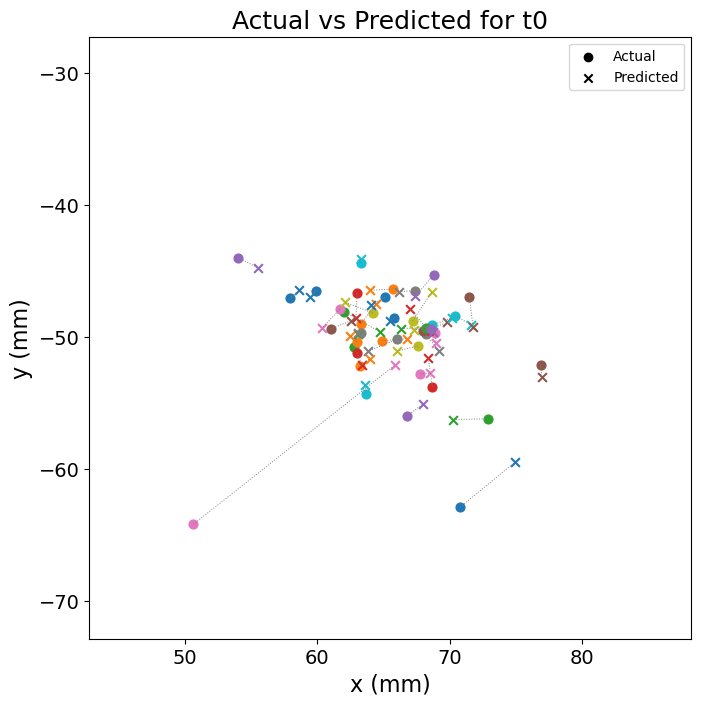

In [53]:
df = pd.read_excel(f"sex_adaptive_report_csv/ans_wide.xlsx")
plot_all_t_with_circles_matplotlib(df,t_list=[0],min_span_mm=43.0)

In [ ]:
landmarks = ['ans']

ValueError: Axis limits cannot be NaN or Inf

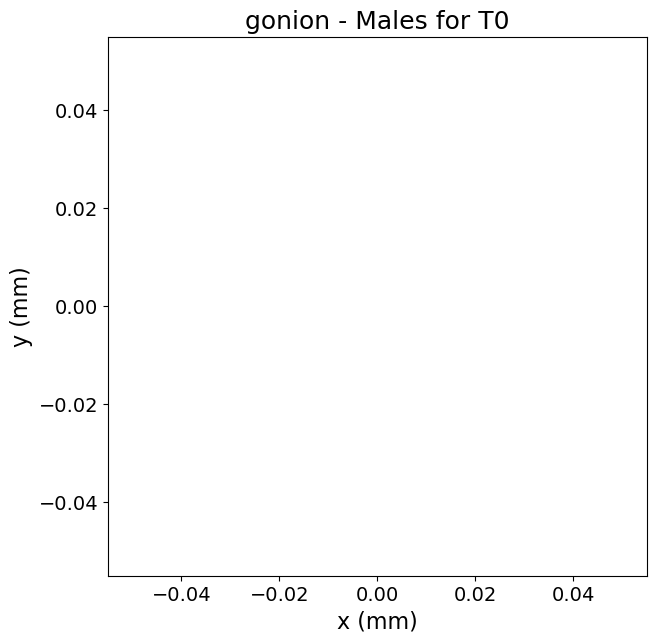

In [4]:
path = "align_csvs/gonion.xlsx"
df = pd.read_excel(path)
male_df = df[df['sex']=='M']
title = f"gonion - Males for T0"
plot_all_t_with_circles_matplotlib(male_df,t_list=[0],save_path=f"sex_adaptive_plots_t0/gonion_male_t0_t1_circles.png",min_span_mm=35.0, title=title)
female_df = df[df['sex']=='F']
title = f"gonion - Females for T0"
plot_all_t_with_circles_matplotlib(female_df,t_list=[0],save_path=f"sex_adaptive_plots_t0/gonion_female_t0_t1_circles.png",min_span_mm=35.0, title=title)

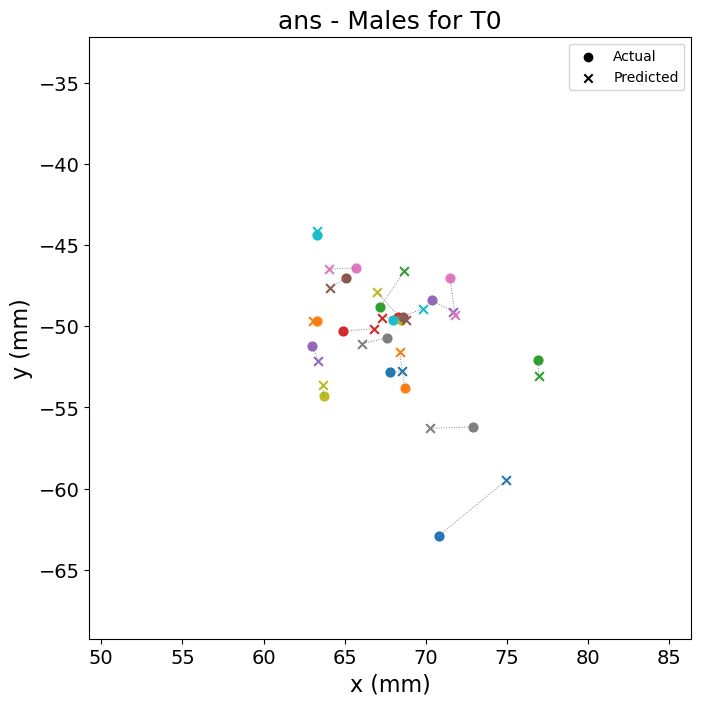

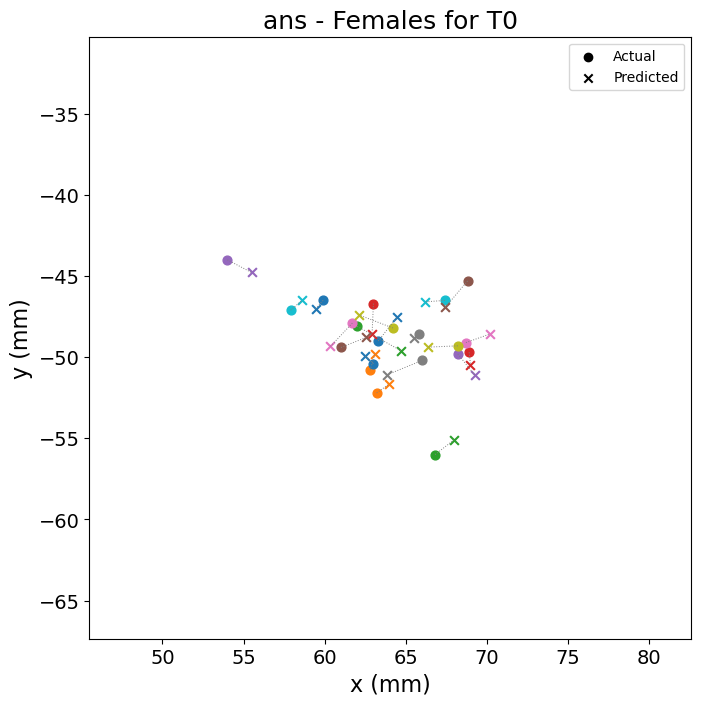

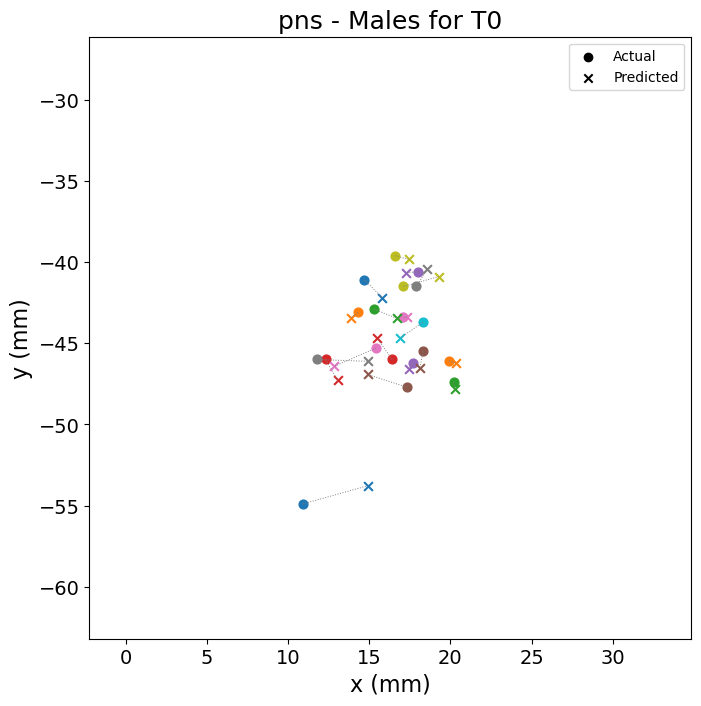

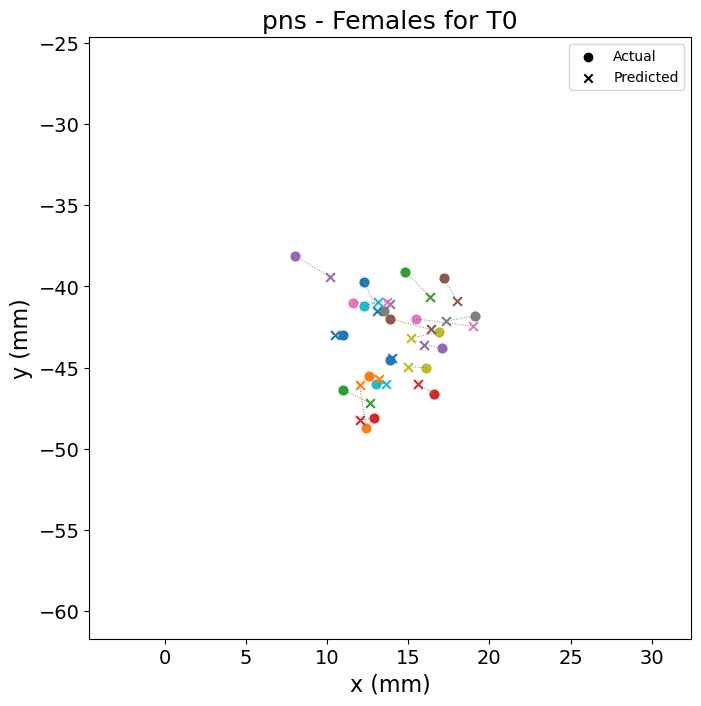

In [4]:
for l in landmarks:
    df = pd.read_excel(f"sex_adaptive_report_csv/{l}_wide.xlsx")
    male_df = df[df['sex']=='M']
    title = f"{l} - Males for T0"
    plot_all_t_with_circles_matplotlib(male_df,t_list=[0],save_path=f"sex_adaptive_plots_t0/{l}_male_t0_t1_circles.png",min_span_mm=35.0, title=title)
    female_df = df[df['sex']=='F']
    title = f"{l} - Females for T0"
    plot_all_t_with_circles_matplotlib(female_df,t_list=[0],save_path=f"sex_adaptive_plots_t0/{l}_female_t0_t1_circles.png",min_span_mm=35.0, title=title)

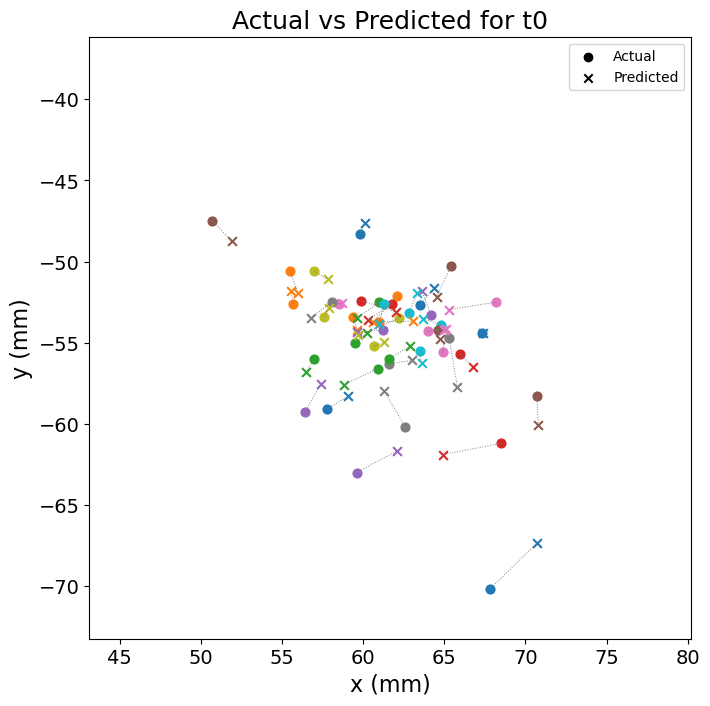

In [19]:
plot_all_t_with_circles_matplotlib(wide_df, t_list=(0,), min_span_mm=35.0)
# or
# plot_all_t_with_circles_matplotlib(wide_df, t_list=[2])


In [62]:
# all subjects
# plot_all_t_with_circles(wide_df)

# # males only
# plot_all_t_with_circles(wide_male)

# # females only
plot_all_t_with_circles(wide_female)


In [63]:
plot_all_t_with_circles(wide_male)

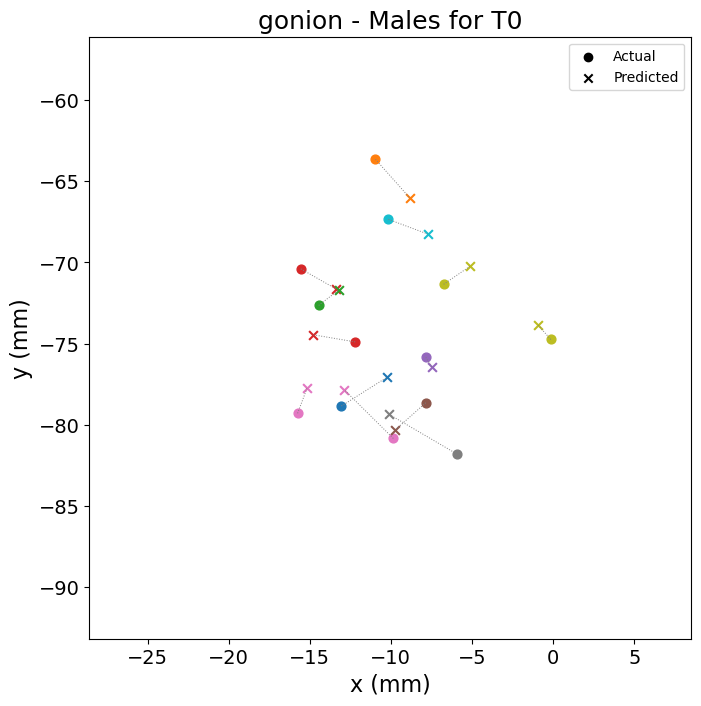

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ---- load ----
path = "align_csvs/gonion.xlsx"
wide_df = pd.read_excel(path)
male_df = wide_df[wide_df['sex']=='M']
female_df = wide_df[wide_df['sex']=='F']

# ---- your function (paste yours here) ----
# plot_all_t_with_circles_matplotlib(...)

# ---- auto-detect available t's like [0,1,2,...] ----
ts = sorted({
    int(m.group(1))
    for c in male_df.columns
    for m in [re.match(r"^t(\d+)x_true$", str(c))]
    if m
})
ts
title = f"gonion - Males for T0"
plot_all_t_with_circles_matplotlib(male_df,t_list=[1],save_path=f"sex_adaptive_plots_t0/gonion_male_t0_t1_circles.png",min_span_mm=35.0, title=title)




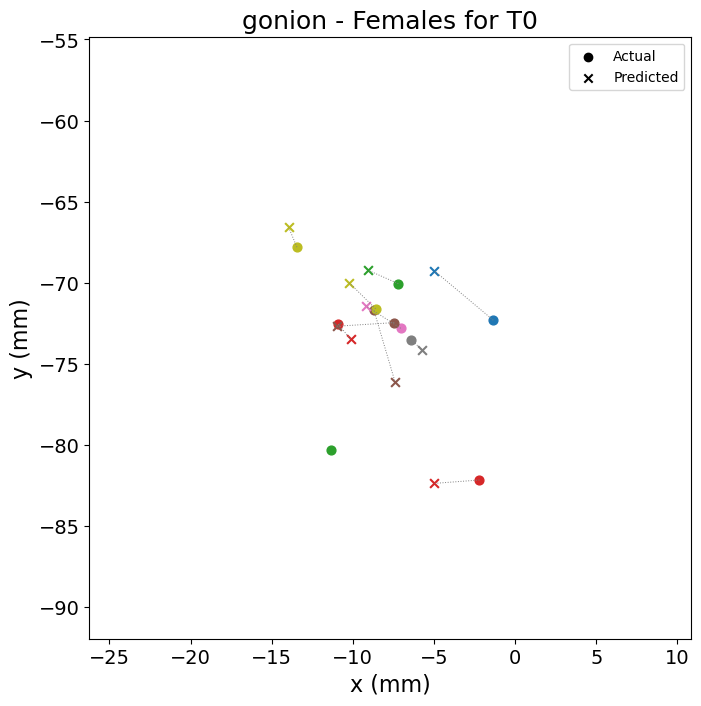

In [13]:
title = f"gonion - Females for T0"
plot_all_t_with_circles_matplotlib(female_df,t_list=[1],save_path=f"sex_adaptive_plots_t0/gonion_female_t0_t1_circles.png",min_span_mm=35.0, title=title)



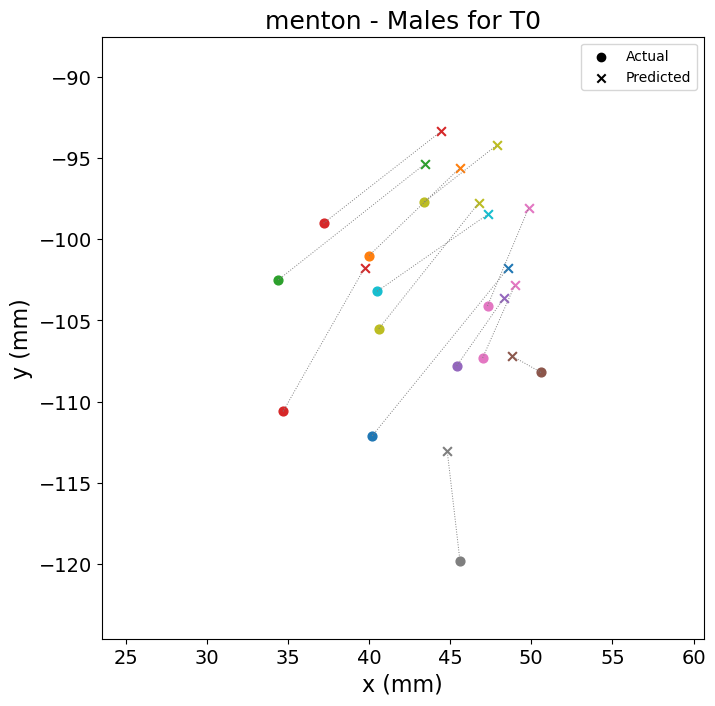

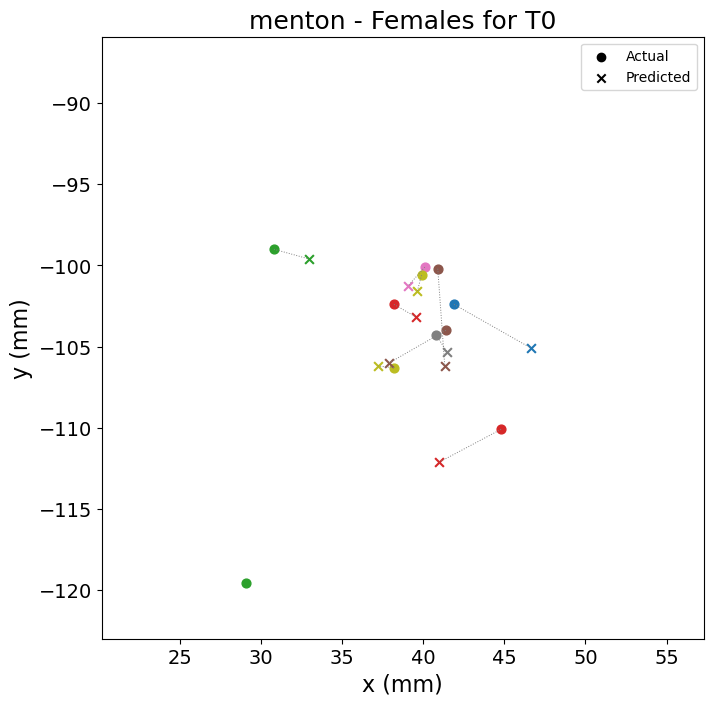

In [15]:
l = 'menton'
path = f"align_csvs/{l}.xlsx"
wide_df = pd.read_excel(path)
male_df = wide_df[wide_df['sex']=='M']
female_df = wide_df[wide_df['sex']=='F']

# ---- your function (paste yours here) ----
# plot_all_t_with_circles_matplotlib(...)

# ---- auto-detect available t's like [0,1,2,...] ----
ts = sorted({
    int(m.group(1))
    for c in wide_df.columns
    for m in [re.match(r"^t(\d+)x_true$", str(c))]
    if m
})

title = f"{l} - Males for T0"
plot_all_t_with_circles_matplotlib(male_df,t_list=[1],save_path=f"sex_adaptive_plots_t0/{l}_male_t0_t1_circles.png",min_span_mm=35.0, title=title)

title = f"{l} - Females for T0"
plot_all_t_with_circles_matplotlib(female_df,t_list=[1],save_path=f"sex_adaptive_plots_t0/{l}_female_t0_t1_circles.png",min_span_mm=35.0, title=title)
